In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, roc_auc_score, recall_score, f1_score
from xgboost import XGBClassifier
import joblib
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

X_train = pd.read_csv("../data/processed/X_train_binary.csv")
y_train = pd.read_csv("../data/processed/y_train_binary.csv").squeeze()
X_test  = pd.read_csv("../data/processed/X_test_binary.csv")
y_test  = pd.read_csv("../data/processed/y_test_binary.csv").squeeze()

print(X_train.shape, y_train.value_counts(normalize=True).round(3).to_dict())

(202944, 21) {0: 0.842, 1: 0.158}


In [9]:
# Calculate scale_pos_weight
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

param_dist = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [3, 4, 5, 6, 7, 8],
    "learning_rate": [0.01, 0.05, 0.1, 0.15, 0.2],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "gamma": [0, 0.1, 0.2, 0.3],
    "scale_pos_weight": [scale_pos_weight]  # keep it fixed
}

scale_pos_weight: 5.35


In [10]:
xgb = XGBClassifier(
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)  # 3-fold to keep it faster

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=25,                    # 25 iterations is a good balance
    scoring="roc_auc",
    cv=skf,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

print("Starting hyperparameter search... (this may take 5–15 minutes)")
random_search.fit(X_train, y_train)

print("\nBest parameters found:")
print(random_search.best_params_)
print(f"\nBest CV ROC-AUC: {random_search.best_score_:.4f}")

Starting hyperparameter search... (this may take 5–15 minutes)
Fitting 3 folds for each of 25 candidates, totalling 75 fits

Best parameters found:
{'subsample': 0.8, 'scale_pos_weight': np.float64(5.345569382777812), 'n_estimators': 300, 'min_child_weight': 7, 'max_depth': 4, 'learning_rate': 0.05, 'gamma': 0.3, 'colsample_bytree': 0.7}

Best CV ROC-AUC: 0.8256


In [11]:
best_xgb = random_search.best_estimator_

y_pred = best_xgb.predict(X_test)
y_proba = best_xgb.predict_proba(X_test)[:, 1]

print("="*60)
print("Tuned XGBoost – Test Set Performance")
print("="*60)
print(classification_report(y_test, y_pred, digits=4))
print(f"ROC-AUC : {roc_auc_score(y_test, y_proba):.4f}")
print(f"Recall  : {recall_score(y_test, y_pred):.4f}")
print(f"F1      : {f1_score(y_test, y_pred):.4f}")

Tuned XGBoost – Test Set Performance
              precision    recall  f1-score   support

           0     0.9468    0.7092    0.8109     42741
           1     0.3361    0.7871    0.4711      7995

    accuracy                         0.7214     50736
   macro avg     0.6415    0.7481    0.6410     50736
weighted avg     0.8506    0.7214    0.7574     50736

ROC-AUC : 0.8253
Recall  : 0.7871
F1      : 0.4711


In [12]:
# Quick untuned baseline for comparison
xgb_untuned = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)
xgb_untuned.fit(X_train, y_train)

untuned_proba = xgb_untuned.predict_proba(X_test)[:, 1]
untuned_pred  = xgb_untuned.predict(X_test)

comparison = pd.DataFrame({
    "Model": ["XGBoost Untuned", "XGBoost Tuned"],
    "ROC-AUC": [
        roc_auc_score(y_test, untuned_proba),
        roc_auc_score(y_test, y_proba)
    ],
    "Recall": [
        recall_score(y_test, untuned_pred),
        recall_score(y_test, y_pred)
    ],
    "F1": [
        f1_score(y_test, untuned_pred),
        f1_score(y_test, y_pred)
    ]
})

print(comparison.round(4).to_string(index=False))

          Model  ROC-AUC  Recall     F1
XGBoost Untuned   0.8223  0.7746 0.4700
  XGBoost Tuned   0.8253  0.7871 0.4711


In [13]:
import os
os.makedirs("../models", exist_ok=True)

joblib.dump(best_xgb, "../models/final_xgb_model.joblib")
print("Final model saved to: models/final_xgb_model.joblib")

# Also save the best parameters for the README
import json
with open("../models/best_params.json", "w") as f:
    json.dump(random_search.best_params_, f, indent=4)

print("Best parameters saved.")

Final model saved to: models/final_xgb_model.joblib
Best parameters saved.


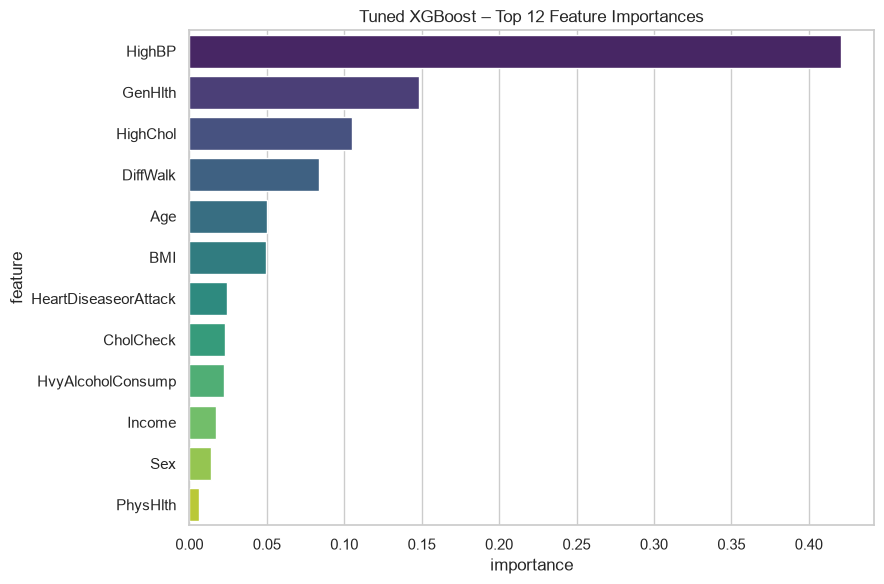

             feature  importance
              HighBP      0.4211
             GenHlth      0.1481
            HighChol      0.1048
            DiffWalk      0.0834
                 Age      0.0503
                 BMI      0.0492
HeartDiseaseorAttack      0.0240
           CholCheck      0.0227
   HvyAlcoholConsump      0.0221
              Income      0.0171
                 Sex      0.0139
            PhysHlth      0.0061


In [14]:
imp = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_xgb.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(data=imp.head(12), x="importance", y="feature", palette="viridis")
plt.title("Tuned XGBoost – Top 12 Feature Importances")
plt.tight_layout()
plt.show()

print(imp.head(12).to_string(index=False))